In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Load the birdnet predictions and validation results

PROB_CORRECT = 0.99

df_pred = pd.read_csv("data/raw/Data Birds/birdnet_predictions.csv")
df_val = pd.read_csv("data/raw/Data Birds/validation_results.csv")

In [3]:
df_pred.shape

(29491, 13)

In [4]:
df_pred.head()

,selection,view,channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,common_name,species_code,confidence,begin_path,file_offset_s,folder
0,1,Spectrogram 1,1,889,892,0,15000,African Black-headed Oriole,abhori1,0.6278,Grid2/RBS02/RBS02_20230622_170000.WAV,889,RBS02
1,2,Spectrogram 1,1,1084,1087,0,15000,African Black-headed Oriole,abhori1,0.3217,Grid2/RBS02/RBS02_20230622_170000.WAV,1084,RBS02
2,1,Spectrogram 1,1,3178,3181,0,15000,Abyssinian Nightjar,abynig1,0.1028,Grid2/RBS02/RBS02_20230622_190000.WAV,3178,RBS02
3,2,Spectrogram 1,1,3574,3577,0,15000,Abyssinian Nightjar,abynig1,0.1456,Grid2/RBS02/RBS02_20230622_190000.WAV,3574,RBS02
4,1,Spectrogram 1,1,1533,1536,0,15000,Abyssinian Nightjar,abynig1,0.1129,Grid2/RBS02/RBS02_20230623_190000.WAV,1533,RBS02


In [5]:
# What proportion of each species is in the dataset

df_pred[["common_name", "species_code"]].value_counts()

common_name                  species_code
African Black-headed Oriole  abhori1         18054
Abyssinian Nightjar          abynig1         10187
Three-banded Plover          thbplo1          1015
Red-billed Firefinch         rebfir2           235
Name: count, dtype: int64

In [6]:
df_pred.groupby("common_name")["confidence"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
common_name,,,,
Abyssinian Nightjar,10187.0,0.1000,0.3223,1.0000
African Black-headed Oriole,18054.0,0.1000,0.2787,0.9985
Red-billed Firefinch,235.0,0.1000,0.1369,0.9073
Three-banded Plover,1015.0,0.1002,0.2858,0.9997


In [7]:
df_val.shape

(551, 6)

In [8]:
df_val.head()

,scientificName,commonName,vBirdNET,filename,confidence,outcome
0,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.107_4_RBS21_20230630_190000.wav,0.107,1
1,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.109_1_RBS14_20230706_010000.wav,0.109,1
2,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.110_1_RBS60_20230702_220000.wav,0.110,1
3,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.113_3_RBS14_20230708_040002.wav,0.113,1
4,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.116_1_RBS55_20230701_220000.wav,0.116,1


In [9]:
df_val[["scientificName", "commonName", "outcome"]].value_counts(sort=False)

scientificName             commonName                   outcome
Caprimulgus poliocephalus  Abyssinian Nightjar          1          117
                                                        0           33
Oriolus larvatus           African Black-headed Oriole  1          150
Lagonosticta senegala      Red-billed Firefinch         1            6
                                                        0           95
Charadrius tricollaris     Three-banded Plover          1          149
                                                        0            1
Name: count, dtype: int64

In [10]:
def logit(p: np.ndarray, eps: float=1e-6) -> np.ndarray:
    # Clip confidence values of 1 which will cause div by zero errors
    p = np.clip(p, a_min=0, a_max=1 - eps)
    return np.log(p / (1 - p))


EPS = 1e-6
df_val["logit_score"] = logit(df_val["confidence"])

In [11]:
df_val

,scientificName,commonName,vBirdNET,filename,confidence,outcome,logit_score
0,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.107_4_RBS21_20230630_190000.wav,0.107,1,-2.121758
1,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.109_1_RBS14_20230706_010000.wav,0.109,1,-2.100997
2,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.110_1_RBS60_20230702_220000.wav,0.110,1,-2.090741
3,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.113_3_RBS14_20230708_040002.wav,0.113,1,-2.060457
4,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.116_1_RBS55_20230701_220000.wav,0.116,1,-2.030867
...,...,...,...,...,...,...,...
546,Charadrius tricollaris,Three-banded Plover,v2.4,0.989_6_RBS75_20230702_080002.wav,0.989,1,4.498799
547,Charadrius tricollaris,Three-banded Plover,v2.4,0.991_1_RBS75_20230701_000000.wav,0.991,1,4.701490
548,Charadrius tricollaris,Three-banded Plover,v2.4,0.991_1_RBS75_20230707_110002.wav,0.991,1,4.701490
549,Charadrius tricollaris,Three-banded Plover,v2.4,0.994_4_RBS75_20230628_160000.wav,0.994,1,5.109978


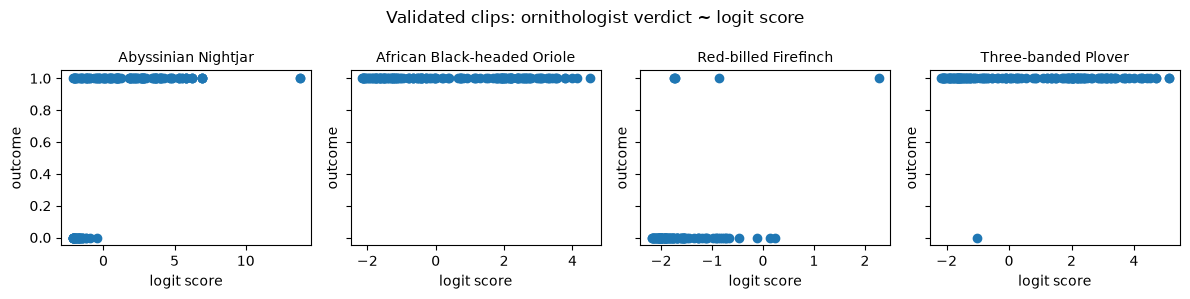

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

i=0
for species, df_species_val in df_val.groupby("commonName"):
    ax[i].scatter(df_species_val["logit_score"], df_species_val["outcome"])
    ax[i].set_title(species, fontsize=10)
    ax[i].set_xlabel("logit score")
    ax[i].set_ylabel("outcome")
    i+=1
fig.suptitle("Validated clips: ornithologist verdict ~ logit score")
fig.tight_layout()

In [13]:
results = {}
thresholds = {}
for species, df_species_val in df_val.groupby("commonName"):
    
    glm_model = smf.glm("outcome ~ logit_score", data=df_species_val, family=sm.families.Binomial())
    result = glm_model.fit()
    
    b0, b1 = result.params
    threshold_logit = (np.log(PROB_CORRECT / (1 - PROB_CORRECT)) - b0) / b1

    results[species] = result
    thresholds[species] = threshold_logit

/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


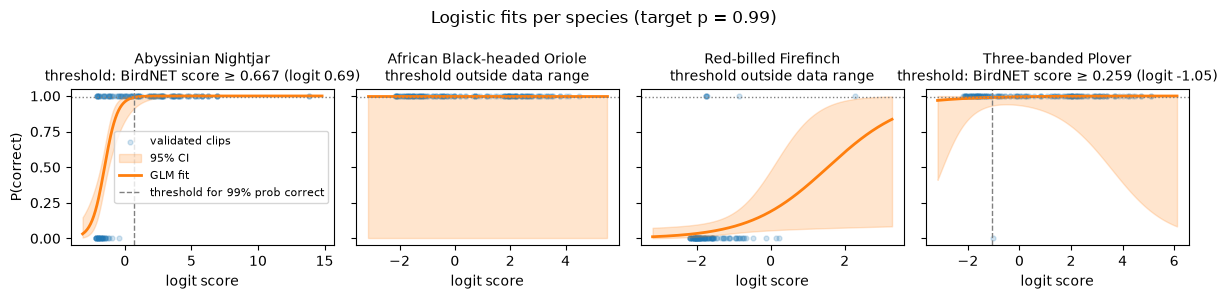

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

for ax, (species, df_species_val) in zip(axes, df_val.groupby("commonName")):
    result = results[species]

    x_grid = np.linspace(df_species_val["logit_score"].min() - 1, df_species_val["logit_score"].max() + 1, 300)
    # Get predictions from the GLM across the x grid, and include the 95% confidence interval
    pred = result.get_prediction(pd.DataFrame({"logit_score": x_grid})).summary_frame(alpha=0.05)

    ax.scatter(df_species_val["logit_score"], df_species_val["outcome"], s=12, alpha=0.2, color="C0", label="validated clips")
    ax.fill_between(x_grid, pred["mean_ci_lower"], pred["mean_ci_upper"], color="C1", alpha=0.2, label="95% CI")
    ax.plot(x_grid, pred["mean"], color="C1", lw=2, label="GLM fit")
    ax.axhline(PROB_CORRECT, color="grey", ls=":", lw=1)

    # plot the threshold logit for each species
    t = thresholds[species]
    if df_species_val["logit_score"].min() <= t <= df_species_val["logit_score"].max():
        ax.axvline(t, color="grey", ls="--", lw=1, label="threshold for 99% prob correct")
        ax.set_title(f"{species}\nthreshold: BirdNET score ≥ {1 / (1 + np.exp(-t)):.3f} (logit {t:.2f})", fontsize=10)

    else:
        ax.set_title(f"{species}\nthreshold outside data range", fontsize=10)
    ax.set_xlabel("logit score")

axes[0].set_ylabel("P(correct)")
axes[0].legend(fontsize=8, loc="center right")

fig.suptitle(f"Logistic fits per species (target p = {PROB_CORRECT})")
fig.tight_layout()